# Reto 03 — Q-Learning: exploración vs. explotación

**Curso:** Aprendizaje por Refuerzo — Universidad EIA  
**Integrantes:** Sebastián Roldán
**Correos:** sebastian.roldan93@eia.edu.co  
**Fecha:** AAAA-MM-DD

> **Pregunta guía:** ¿cómo cambia el aprendizaje de una política cuando Q-Learning usa ε-greedy, ε-greedy con inicialización optimista, UCB o Softmax en entornos con distinta estructura de recompensas?

## Objetivos

- Implementar Q-Learning tabular respetando la API de Gymnasium.
- Separar la actualización de valor de la estrategia de selección.
- Comparar cuatro mecanismos de exploración bajo condiciones reproducibles.
- Evaluar aprendizaje, estabilidad y desempeño de la política final.
- Sustentar decisiones con métricas, gráficas y evidencia experimental.


## Organización en dos clases

### Clase 1 — Construcción y verificación

1. Reconocer `FrozenLake-v1`, `Blackjack-v1` y `Taxi-v4`.
2. Implementar las cuatro estrategias de selección.
3. Implementar el ciclo de Q-Learning y sus pruebas unitarias pequeñas.
4. Ejecutar un experimento piloto en FrozenLake.

**Hito al terminar:** las funciones pasan las verificaciones y una corrida produce curvas coherentes.

### Clase 2 — Experimento y comunicación

1. Ejecutar la comparación principal en los tres escenarios.
2. Evaluar las políticas sin exploración.
3. Realizar sensibilidad de hiperparámetros.
4. Interpretar resultados, documentar IA y redactar conclusiones.

**Hito al terminar:** tabla resumen, visualizaciones, respuestas y conclusiones completas.


## 1. Preparación del entorno


In [1]:
from __future__ import annotations

from collections.abc import Callable

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 2026
ALPHA = 0.10
GAMMA = 0.99
N_RUNS = 30

ENV_CONFIG = {
    "FrozenLake-v1": {"episodes": 2_000, "max_steps": 100, "kwargs": {"is_slippery": True}},
    "Blackjack-v1": {"episodes": 10_000, "max_steps": 100, "kwargs": {"sab": True}},
    "Taxi-v4": {"episodes": 2_000, "max_steps": 200, "kwargs": {}},
}

STRATEGIES = {
    "epsilon_greedy": {"epsilon": 0.10, "q0": 0.0},
    "optimistic": {"epsilon": 0.01, "q0": 5.0},
    "ucb": {"c": 1.0, "q0": 0.0},
    "softmax": {"temperature": 0.50, "q0": 0.0},
}


## 2. Reconocimiento de los escenarios

Para cada entorno, reporte número de estados y acciones, rango de recompensas, condición terminal y dificultad esperada. Observe que `reset()` devuelve `(observation, info)` y `step()` devuelve `(observation, reward, terminated, truncated, info)`. Un episodio termina si `terminated or truncated`. Blackjack devuelve una tupla, por lo que se suministra una codificación tabular reproducible.


In [2]:
def tabular_space_size(observation_space) -> int:
    """Número de estados de un espacio Discrete o Tuple de Discrete."""
    if isinstance(observation_space, gym.spaces.Discrete):
        return int(observation_space.n)
    if isinstance(observation_space, gym.spaces.Tuple):
        return int(np.prod([space.n for space in observation_space.spaces]))
    raise TypeError("Este reto solo admite observaciones discretas.")


def encode_observation(observation, observation_space) -> int:
    """Convierte una observación discreta, incluida una tupla, en un índice."""
    if isinstance(observation_space, gym.spaces.Discrete):
        return int(observation)
    dimensions = tuple(space.n for space in observation_space.spaces)
    return int(np.ravel_multi_index(tuple(observation), dimensions))


for env_id, config in ENV_CONFIG.items():
    env = gym.make(env_id, **config["kwargs"])
    observation, info = env.reset(seed=SEED)
    print(env_id, "| estados tabulares:", tabular_space_size(env.observation_space), "| acciones:", env.action_space.n)
    print("  observación inicial:", observation, "| acciones válidas:", list(range(env.action_space.n)))
    env.close()


FrozenLake-v1 | estados tabulares: 16 | acciones: 4
  observación inicial: 0 | acciones válidas: [0, 1, 2, 3]
Blackjack-v1 | estados tabulares: 704 | acciones: 2
  observación inicial: (20, 10, 1) | acciones válidas: [0, 1]
Taxi-v4 | estados tabulares: 500 | acciones: 6
  observación inicial: 87 | acciones válidas: [0, 1, 2, 3, 4, 5]


### Análisis previo

Complete antes de entrenar:

| Entorno | Estados | Acciones | Recompensas relevantes | ¿Qué dificulta explorar? |
|---|---:|---:|---|---|
| FrozenLake-v1 | TODO | TODO | TODO | TODO |
| Blackjack-v1 | TODO | TODO | TODO | TODO |
| Taxi-v4 | TODO | TODO | TODO | TODO |


## 3. Estrategias de exploración

Todas las funciones deben devolver una acción válida y resolver empates aleatoriamente. `counts[s, a]` registra cuántas veces se eligió la acción `a` en el estado `s`.

- **ε-greedy:** acción aleatoria con probabilidad ε; en otro caso, una acción greedy.
- **ε-greedy optimista:** misma regla, pero la tabla inicia en `Q0 > 0`; explique por qué esto incentiva explorar.
- **UCB:** seleccione primero acciones no visitadas; luego maximice `Q(s,a) + c sqrt(log(N(s)+1) / N(s,a))`.
- **Softmax:** muestree según `softmax(Q(s,·)/τ)` usando estabilización numérica.


In [11]:
def random_argmax(values: np.ndarray, rng: np.random.Generator) -> int:
    """Devuelve aleatoriamente uno de los índices con valor máximo."""
    max = np.max(values)
    indices_max = np.flatnonzero(values == max)
    return rng.choice(indices_max)


def select_action(
    q: np.ndarray,
    counts: np.ndarray,
    state: int,
    strategy: str,
    rng: np.random.Generator,
    *,
    epsilon: float = 0.10,
    c: float = 1.0,
    temperature: float = 0.50,
) -> int:
    """Selecciona una acción usando la estrategia solicitada."""
    valid_strategies = {"epsilon_greedy", "optimistic", "ucb", "softmax"}

    if strategy not in valid_strategies:
        raise ValueError(f"strategy debe ser una de {sorted(valid_strategies)}")
    if not 0 <= epsilon <= 1:
        raise ValueError("epsilon debe estar entre 0 y 1.")
    if c < 0:
        raise ValueError("c debe ser mayor o igual a 0.")
    if temperature <= 0:
        raise ValueError("temperature debe ser mayor que 0.")
    if q.ndim != 2 or counts.shape != q.shape:
        raise ValueError("q y counts deben tener la misma forma bidimensional.")
    if not 0 <= state < q.shape[0]:
        raise IndexError("state está fuera de la tabla Q.")

    n_actions = q.shape[1]

    # ε-greedy e inicio optimista comparten la regla de selección. La diferencia
    # del método optimista está en que Q se inicializa con q0 > 0.
    if strategy in {"epsilon_greedy", "optimistic"}:
        if rng.random() < epsilon:
            return int(rng.integers(n_actions))
        return random_argmax(q[state], rng)

    if strategy == "ucb":
        # Primero se obliga a probar acciones todavía no visitadas en ese estado.
        unvisited = np.flatnonzero(counts[state] == 0)
        if unvisited.size > 0:
            return int(rng.choice(unvisited))

        state_visits = counts[state].sum()
        bonus = c * np.sqrt(np.log(state_visits + 1.0) / counts[state])
        scores = q[state] + bonus
        return random_argmax(scores, rng)

    # Softmax / exploración de Boltzmann, con estabilización numérica.
    logits = q[state] / temperature
    logits = logits - np.max(logits)
    weights = np.exp(logits)
    probabilities = weights / weights.sum()
    return int(rng.choice(n_actions, p=probabilities))


### Pruebas pequeñas de selección


In [ ]:
# Ejecute esta celda después de implementar select_action.
q_test = np.array([[1.0, 3.0, 3.0, 0.0]])
n_test = np.array([[5, 5, 5, 0]])

# Acciones válidas:
for strategy in ["epsilon_greedy", "optimistic", "ucb", "softmax"]:
    rng = np.random.default_rng(SEED)
    actions = [select_action(q_test, n_test, 0, strategy, rng) for _ in range(100)]
    assert all(0 <= action < q_test.shape[1] for action in actions)

# Empates no deterministas
rng = np.random.default_rng(SEED)
tied_actions = [random_argmax(q_test[0], rng) for _ in range(100)]
assert set(tied_actions).issubset({1, 2})
assert len(set(tied_actions)) == 2

# Acciones no visitadas
rng = np.random.default_rng(SEED)
assert select_action(q_test, n_test, 0, "ucb", rng, c=1.0) == 3

# Validación parámetros
for bad_call in [lambda: select_action(q_test, n_test, 0, "epsilon_greedy", np.random.default_rng(SEED), epsilon=1.1),
    lambda: select_action(q_test, n_test, 0, "ucb", np.random.default_rng(SEED), c=-1),
    lambda: select_action(q_test, n_test, 0, "softmax", np.random.default_rng(SEED), temperature=0),
    lambda: select_action(q_test, n_test, 0, "no_existe", np.random.default_rng(SEED))]:
    try:
        bad_call()
        raise AssertionError("La validación esperada no se activó.")
    except ValueError:
        pass


## 4. Q-Learning tabular

Implemente la actualización:

$$Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha [R_{t+1} + \gamma(1-d)\max_a Q(S_{t+1},a)-Q(S_t,A_t)],$$

donde `d` es verdadero cuando la transición termina el MDP (`terminated`). Para un truncamiento por límite de tiempo, documente si realiza *bootstrap* y mantenga la decisión consistente. No actualice hacia el valor del estado terminal.


In [14]:
def q_learning_target(
    reward: float,
    next_q_values: np.ndarray,
    gamma: float,
    terminated: bool,
) -> float:
    """Calcula el target de Q-Learning tratando terminales sin bootstrap."""
    if terminated:
        return float(reward)
    return float(reward + gamma * np.max(next_q_values))


def train_q_learning(
    env_id: str,
    strategy: str,
    episodes: int,
    max_steps: int,
    alpha: float,
    gamma: float,
    seed: int,
    env_kwargs: dict | None = None,
    **strategy_params,
) -> tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    """Entrena Q-Learning y devuelve Q, historial por episodio y conteos."""
    if episodes <= 0 or max_steps <= 0:
        raise ValueError("episodes y max_steps deben ser positivos.")
    if not 0 < alpha <= 1:
        raise ValueError("alpha debe estar en (0, 1].")
    if not 0 <= gamma <= 1:
        raise ValueError("gamma debe estar entre 0 y 1.")

    env_kwargs = {} if env_kwargs is None else dict(env_kwargs)
    params = dict(strategy_params)
    q0 = float(params.pop("q0", 0.0))
    rng = np.random.default_rng(seed)
    env = gym.make(env_id, **env_kwargs)

    try:
        n_states = tabular_space_size(env.observation_space)
        n_actions = int(env.action_space.n)
        q = np.full((n_states, n_actions), q0, dtype=float)
        counts = np.zeros((n_states, n_actions), dtype=np.int64)
        history = []

        for episode in range(episodes):
            # Se fija la semilla al inicio de cada corrida y luego el ambiente
            # continúa su propia secuencia pseudoaleatoria. Así, run=2026 y
            # run=2027 son corridas distintas sin reciclar casi todas las semillas.
            if episode == 0:
                observation, info = env.reset(seed=seed)
            else:
                observation, info = env.reset()
            state = encode_observation(observation, env.observation_space)

            episode_return = 0.0
            td_errors = []
            success = False
            episode_length = 0

            for step in range(1, max_steps + 1):
                action = select_action(q, counts, state, strategy, rng, **params)
                counts[state, action] += 1

                next_observation, reward, terminated, truncated, info = env.step(action)
                next_state = encode_observation(next_observation, env.observation_space)

                target = q_learning_target(reward, q[next_state], gamma, terminated)
                td_error = target - q[state, action]
                q[state, action] += alpha * td_error

                episode_return += float(reward)
                td_errors.append(abs(float(td_error)))
                success = success or (reward > 0)
                episode_length = step
                state = next_state

                # Si el wrapper de Gymnasium trunca o llegamos a nuestro presupuesto,
                # dejamos de interactuar. La actualización anterior sí hizo bootstrap
                # salvo que terminated=True.
                if terminated or truncated or step == max_steps:
                    break

            history.append(
                {
                    "episode": episode + 1,
                    "return": episode_return,
                    "length": episode_length,
                    "success": int(success),
                    "td_error_mean": float(np.mean(td_errors)) if td_errors else 0.0,
                }
            )

        return q, pd.DataFrame(history), counts
    finally:
        env.close()


### Contrato mínimo y verificaciones

Para una corrida corta compruebe:

- `Q.shape == (n_states, n_actions)` y todos sus valores son finitos.
- Hay exactamente una fila por episodio.
- `1 <= length <= max_steps`.
- `counts.sum()` coincide con el total de pasos registrados.
- La misma semilla reproduce resultados; otra semilla puede cambiarlos.
- Con `gamma=0`, el objetivo no contiene el valor del siguiente estado.
- Una transición terminal usa como objetivo únicamente la recompensa.


In [ ]:
short_kwargs = ENV_CONFIG["FrozenLake-v1"]["kwargs"]
q_short, h_short, counts_short = train_q_learning(env_id="FrozenLake-v1", strategy="epsilon_greedy",
    episodes=20, max_steps=100, alpha=ALPHA, gamma=GAMMA, seed=SEED, env_kwargs=short_kwargs, epsilon=0.10, q0=0.0)

assert q_short.shape == (16, 4)
assert np.all(np.isfinite(q_short))
assert len(h_short) == 20
assert h_short["length"].between(1, 100).all()
assert counts_short.sum() == h_short["length"].sum()

Contrato de Q-Learning superado.


## 5. Evaluación sin exploración

Evaluar con la misma exploración usada durante el entrenamiento mezcla dos efectos. Implemente una evaluación separada que seleccione acciones greedy, no actualice `Q` y use semillas distintas a las de entrenamiento. En empates, conserve la selección aleatoria.


In [17]:
def evaluate_policy(
    env_id: str,
    q: np.ndarray,
    n_episodes: int,
    max_steps: int,
    seed: int,
    env_kwargs: dict | None = None,
) -> pd.DataFrame:
    """Evalúa la política greedy sin modificar Q."""
    if n_episodes <= 0 or max_steps <= 0:
        raise ValueError("n_episodes y max_steps deben ser positivos.")

    env_kwargs = {} if env_kwargs is None else dict(env_kwargs)
    rng = np.random.default_rng(seed)
    env = gym.make(env_id, **env_kwargs)

    try:
        n_states = tabular_space_size(env.observation_space)
        n_actions = int(env.action_space.n)
        if q.shape != (n_states, n_actions):
            raise ValueError(f"Q tiene forma {q.shape}, pero se esperaba {(n_states, n_actions)}")

        rows = []
        for episode in range(n_episodes):
            if episode == 0:
                observation, info = env.reset(seed=seed)
            else:
                observation, info = env.reset()
            state = encode_observation(observation, env.observation_space)
            episode_return = 0.0
            success = False
            episode_length = 0

            for step in range(1, max_steps + 1):
                action = random_argmax(q[state], rng)
                next_observation, reward, terminated, truncated, info = env.step(action)
                state = encode_observation(next_observation, env.observation_space)

                episode_return += float(reward)
                success = success or (reward > 0)
                episode_length = step

                if terminated or truncated or step == max_steps:
                    break

            rows.append(
                {
                    "episode": episode + 1,
                    "return": episode_return,
                    "length": episode_length,
                    "success": int(success),
                }
            )

        return pd.DataFrame(rows)
    finally:
        env.close()


## 6. Experimento piloto — cierre de la clase 1

Entrene las cuatro estrategias en `FrozenLake-v1` durante 300 episodios y una sola corrida. Grafique retorno y éxito suavizados con una media móvil de 50 episodios. Use este piloto para detectar errores; **no** lo presente como evidencia concluyente.


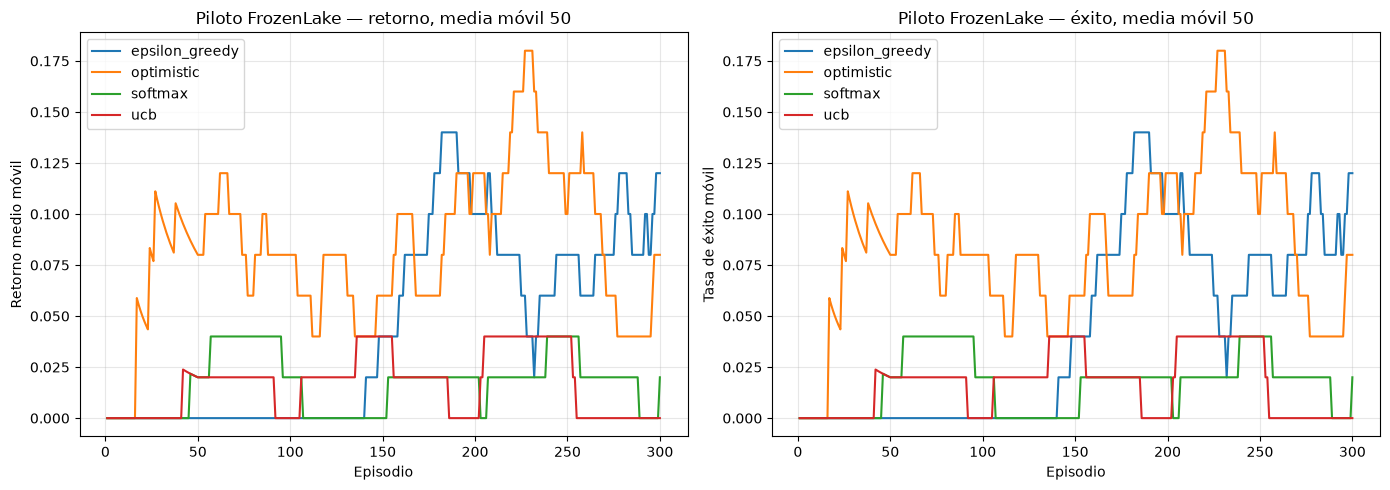

In [19]:
pilot_histories = []
for strategy, params in STRATEGIES.items():
    q_pilot, h_pilot, counts_pilot = train_q_learning(
        env_id="FrozenLake-v1",
        strategy=strategy,
        episodes=300,
        max_steps=ENV_CONFIG["FrozenLake-v1"]["max_steps"],
        alpha=ALPHA,
        gamma=GAMMA,
        seed=SEED,
        env_kwargs=ENV_CONFIG["FrozenLake-v1"]["kwargs"],
        **params,
    )
    h_pilot = h_pilot.copy()
    h_pilot["strategy"] = strategy
    pilot_histories.append(h_pilot)

pilot_results = pd.concat(pilot_histories, ignore_index=True)
pilot_results["return_ma50"] = pilot_results.groupby("strategy")["return"].transform(
    lambda s: s.rolling(50, min_periods=1).mean()
)
pilot_results["success_ma50"] = pilot_results.groupby("strategy")["success"].transform(
    lambda s: s.rolling(50, min_periods=1).mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for strategy, group in pilot_results.groupby("strategy"):
    axes[0].plot(group["episode"], group["return_ma50"], label=strategy)
    axes[1].plot(group["episode"], group["success_ma50"], label=strategy)

axes[0].set_title("Piloto FrozenLake — retorno, media móvil 50")
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel("Retorno medio móvil")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("Piloto FrozenLake — éxito, media móvil 50")
axes[1].set_xlabel("Episodio")
axes[1].set_ylabel("Tasa de éxito móvil")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Comparación principal — clase 2

Use los valores de `ENV_CONFIG`, al menos 30 corridas independientes y las mismas semillas por entorno para las cuatro estrategias. Esto empareja la aleatoriedad experimental sin reutilizar el mismo generador. Evalúe cada tabla final durante 100 episodios con semillas nuevas.

Registre por episodio: entorno, algoritmo, corrida, episodio, retorno, longitud, éxito y error TD medio. Registre por evaluación: retorno, longitud y éxito. Justifique cualquier reducción de corridas realizada por límites computacionales.


In [21]:
# Guardamos una Q representativa (corrida 0) para visualizaciones posteriores.
REPRESENTATIVE_Q: dict[tuple[str, str], np.ndarray] = {}


def run_experiment(
    env_config: dict,
    strategies: dict,
    n_runs: int = N_RUNS,
    base_seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Ejecuta entrenamiento y evaluación para todos los escenarios."""
    if n_runs <= 0:
        raise ValueError("n_runs debe ser positivo.")

    all_training = []
    all_evaluation = []
    REPRESENTATIVE_Q.clear()

    for env_index, (env_id, config) in enumerate(env_config.items()):
        print(f"Ejecutando {env_id}...")

        for run in range(n_runs):
            train_seed = base_seed + run
            # Familia separada de semillas para evaluación, emparejada entre estrategias.
            eval_seed = base_seed + 100_000 + env_index * 10_000 + run * 100

            for strategy, params in strategies.items():
                q, history, counts = train_q_learning(
                    env_id=env_id,
                    strategy=strategy,
                    episodes=config["episodes"],
                    max_steps=config["max_steps"],
                    alpha=ALPHA,
                    gamma=GAMMA,
                    seed=train_seed,
                    env_kwargs=config.get("kwargs", {}),
                    **params,
                )

                visited_pairs = int(np.count_nonzero(counts))
                coverage = visited_pairs / counts.size

                history = history.copy()
                history["env"] = env_id
                history["strategy"] = strategy
                history["run"] = run
                history["sa_visited_pairs"] = visited_pairs
                history["sa_coverage"] = coverage
                all_training.append(history)

                evaluation = evaluate_policy(
                    env_id=env_id,
                    q=q,
                    n_episodes=100,
                    max_steps=config["max_steps"],
                    seed=eval_seed,
                    env_kwargs=config.get("kwargs", {}),
                )
                evaluation["env"] = env_id
                evaluation["strategy"] = strategy
                evaluation["run"] = run
                all_evaluation.append(evaluation)

                if run == 0:
                    REPRESENTATIVE_Q[(env_id, strategy)] = q.copy()

    return pd.concat(all_training, ignore_index=True), pd.concat(all_evaluation, ignore_index=True)


training_results, evaluation_results = run_experiment(ENV_CONFIG, STRATEGIES)


Ejecutando FrozenLake-v1...
Ejecutando Blackjack-v1...
Ejecutando Taxi-v4...


## 8. Métricas y visualizaciones obligatorias

Construya una tabla por entorno y algoritmo con:

1. Retorno medio de entrenamiento en el último 10 % de episodios.
2. Área bajo la curva del retorno medio (calidad durante el aprendizaje).
3. Tasa de éxito final durante evaluación.
4. Retorno medio de evaluación.
5. Longitud media de evaluación.
6. Intervalo de confianza del 95 % entre corridas (indique el método).

Incluya, como mínimo:

- Curvas de retorno por episodio, media móvil y banda de IC 95 %.
- Curvas de éxito acumulado o móvil.
- Comparación del retorno de evaluación por entorno.
- Mapa de calor de `max_a Q(s,a)` o visualización de política para al menos un entorno.

No promedie directamente episodios de entornos con escalas de recompensa distintas en una única cifra global.


In [ ]:
# Número máximo de episodios por entorno, estrategia y corrida
training_results["max_episode"] = (training_results.groupby(["env", "strategy", "run"])["episode"].transform("max"))

# Quedarnos con el último 10% de cada entrenamiento
last_10 = training_results[training_results["episode"] > training_results["max_episode"] * 0.9].copy()


# Resumen del entrenamiento
training_summary = (last_10.groupby(["env", "strategy"]).agg(train_return_last10=("return", "mean"),
        train_success_last10=("success", "mean"), sa_coverage_mean=("sa_coverage", "mean")).reset_index())


# Resumen de la evaluación
evaluation_summary = (evaluation_results.groupby(["env", "strategy"]).agg(eval_return_mean=("return", "mean"),
    eval_success_rate=("success", "mean"), eval_length_mean=("length", "mean")).reset_index())


# Unir resultados
summary = pd.merge(training_summary,evaluation_summary,on=["env", "strategy"])


# Ordenar resultados
summary = summary.sort_values(["env", "eval_return_mean"],ascending=[True, False]).reset_index(drop=True)


display(summary.round(4))

,env,strategy,train_return_last10,train_success_last10,sa_coverage_mean,eval_return_mean,eval_success_rate,eval_length_mean
0,Blackjack-v1,ucb,-0.1125,0.4053,0.3967,-0.0333,0.4427,1.5017
1,Blackjack-v1,epsilon_greedy,-0.1132,0.4039,0.3896,-0.0367,0.4403,1.5357
2,Blackjack-v1,softmax,-0.1728,0.3809,0.3945,-0.0557,0.4353,1.4707
3,Blackjack-v1,optimistic,-0.1519,0.3871,0.3969,-0.1060,0.4117,1.4687
4,FrozenLake-v1,optimistic,0.6817,0.6817,0.6875,0.7223,0.7223,45.1367
5,FrozenLake-v1,epsilon_greedy,0.3858,0.3858,0.6870,0.6840,0.6840,40.1323
6,FrozenLake-v1,ucb,0.4167,0.4167,0.6875,0.5587,0.5587,47.6090
7,FrozenLake-v1,softmax,0.0208,0.0208,0.6875,0.4530,0.4530,32.9873
8,Taxi-v4,ucb,7.3307,1.0000,0.8000,-8.9957,0.9177,28.2667
9,Taxi-v4,epsilon_greedy,1.8383,1.0000,0.7993,-12.6920,0.9050,30.4970


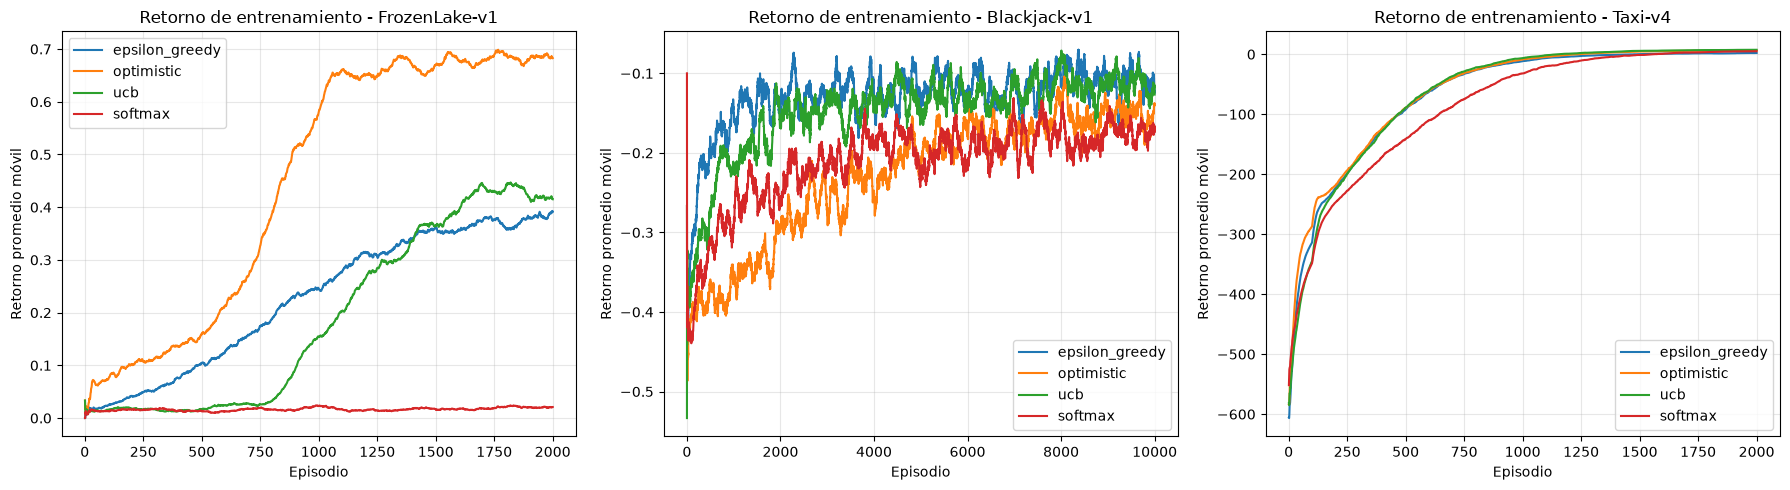

In [26]:
rolling_training = training_results.copy()

rolling_training["return_ma"] = (
    rolling_training
    .groupby(["env", "strategy", "run"])["return"]
    .transform(lambda x: x.rolling(100, min_periods=1).mean())
)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, env_id in zip(axes, ENV_CONFIG):

    env_data = rolling_training[
        rolling_training["env"] == env_id
    ]

    for strategy in STRATEGIES:

        strategy_data = env_data[
            env_data["strategy"] == strategy
        ]

        curve = (
            strategy_data
            .groupby("episode")["return_ma"]
            .mean()
        )

        ax.plot(
            curve.index,
            curve.values,
            label=strategy
        )

    ax.set_title(f"Retorno de entrenamiento - {env_id}")
    ax.set_xlabel("Episodio")
    ax.set_ylabel("Retorno promedio móvil")
    ax.legend()
    ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

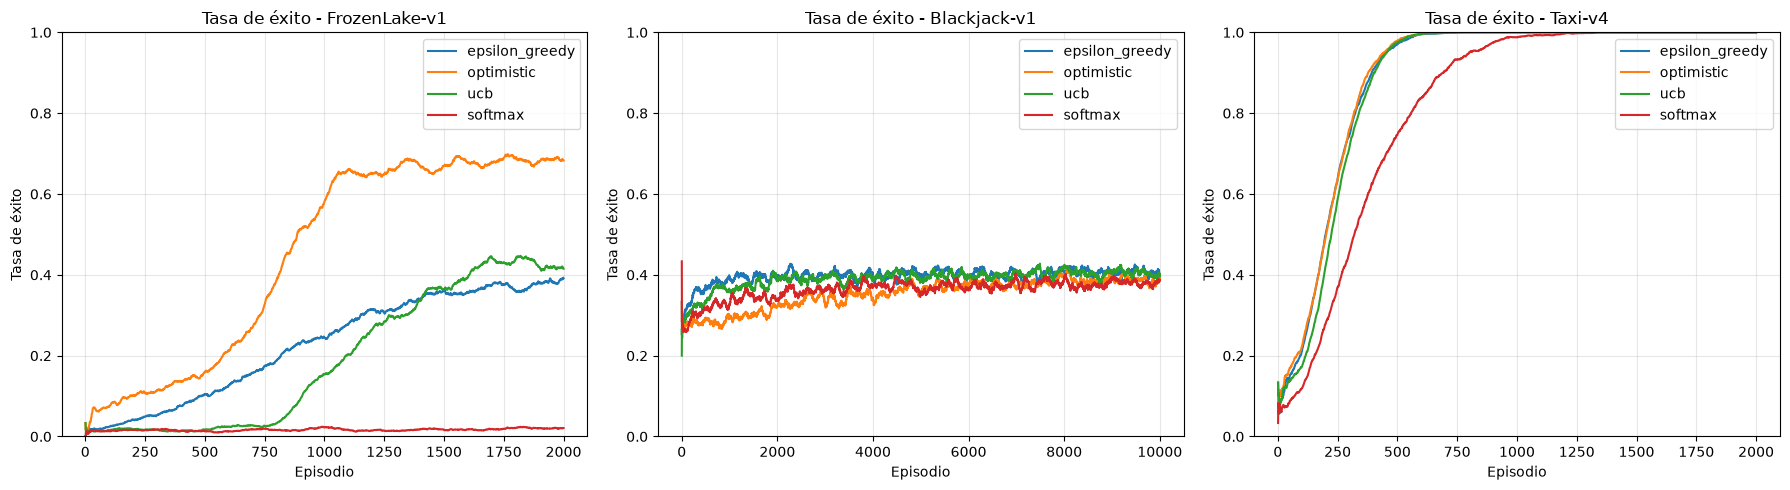

In [27]:
rolling_training["success_ma"] = (
    rolling_training
    .groupby(["env", "strategy", "run"])["success"]
    .transform(lambda x: x.rolling(100, min_periods=1).mean())
)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, env_id in zip(axes, ENV_CONFIG):

    env_data = rolling_training[
        rolling_training["env"] == env_id
    ]

    for strategy in STRATEGIES:

        strategy_data = env_data[
            env_data["strategy"] == strategy
        ]

        curve = (
            strategy_data
            .groupby("episode")["success_ma"]
            .mean()
        )

        ax.plot(
            curve.index,
            curve.values,
            label=strategy
        )

    ax.set_title(f"Tasa de éxito - {env_id}")
    ax.set_xlabel("Episodio")
    ax.set_ylabel("Tasa de éxito")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

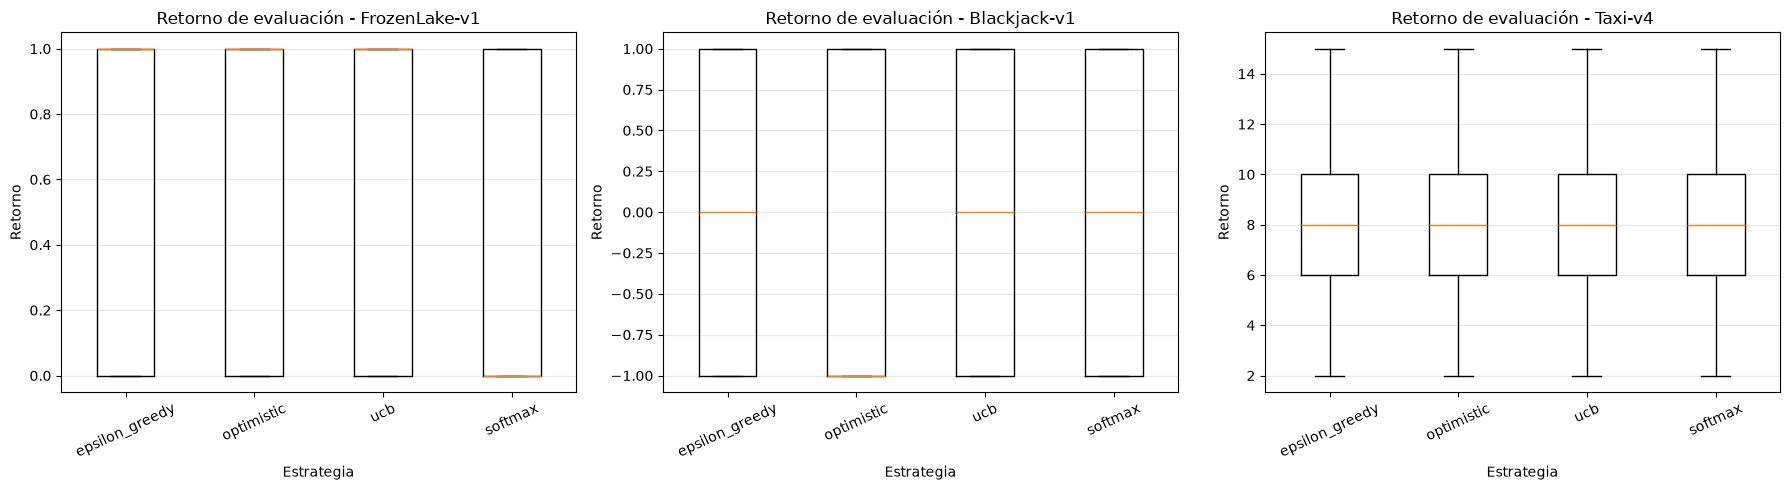

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strategy_order = list(STRATEGIES.keys())

for ax, env_id in zip(axes, ENV_CONFIG):

    env_data = evaluation_results[
        evaluation_results["env"] == env_id
    ]

    data = []

    for strategy in strategy_order:

        returns = env_data[
            env_data["strategy"] == strategy
        ]["return"]

        data.append(returns)

    ax.boxplot(
        data,
        tick_labels=strategy_order,
        showfliers=False
    )

    ax.set_title(f"Retorno de evaluación - {env_id}")
    ax.set_xlabel("Estrategia")
    ax.set_ylabel("Retorno")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Mejor estrategia en FrozenLake: optimistic


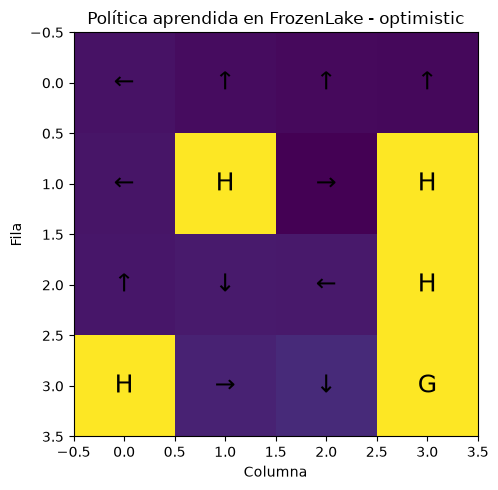

In [29]:
frozen_results = summary[
    summary["env"] == "FrozenLake-v1"
]

best_strategy = frozen_results.loc[
    frozen_results["eval_return_mean"].idxmax(),
    "strategy"
]

print("Mejor estrategia en FrozenLake:", best_strategy)


# Recuperar la tabla Q
q_frozen = REPRESENTATIVE_Q[
    ("FrozenLake-v1", best_strategy)
]


# Mejor acción de cada estado
policy = np.argmax(q_frozen, axis=1).reshape(4, 4)


# Valor máximo de cada estado
state_values = np.max(
    q_frozen,
    axis=1
).reshape(4, 4)


arrows = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}


map_tiles = np.array([
    list("SFFF"),
    list("FHFH"),
    list("FFFH"),
    list("HFFG")
])


fig, ax = plt.subplots(figsize=(6, 5))

ax.imshow(state_values)


for row in range(4):

    for col in range(4):

        tile = map_tiles[row, col]

        if tile == "H":
            text = "H"

        elif tile == "G":
            text = "G"

        else:
            text = arrows[policy[row, col]]

        ax.text(
            col,
            row,
            text,
            ha="center",
            va="center",
            fontsize=18
        )


ax.set_title(
    f"Política aprendida en FrozenLake - {best_strategy}"
)

ax.set_xlabel("Columna")
ax.set_ylabel("Fila")

plt.tight_layout()
plt.show()

## 9. Sensibilidad de hiperparámetros

Seleccione el entorno donde las estrategias difirieron más y compare:

| Estrategia | Valores mínimos |
|---|---|
| ε-greedy | ε ∈ {0.01, 0.10, 0.30} |
| Optimista | Q0 ∈ {1, 5, 10}, con ε = 0.01 |
| UCB | c ∈ {0.25, 1, 2} |
| Softmax | τ ∈ {0.10, 0.50, 1.0} |

Puede usar 10 corridas, pero mantenga constantes episodios, α, γ y semillas. Presente una gráfica o tabla y explique el patrón; no elija un valor mirando únicamente una corrida.


Entorno elegido para sensibilidad: Taxi-v4


,strategy,hiperparametro,valor,train_return,eval_return,eval_success
0,epsilon_greedy,epsilon,0.01,6.8685,-28.568,0.892
1,epsilon_greedy,epsilon,0.10,1.9205,-12.244,0.910
2,epsilon_greedy,epsilon,0.30,-15.8440,-11.301,0.906
3,optimistic,Q0,1.00,6.4300,-33.003,0.897
4,optimistic,Q0,5.00,6.5245,-44.259,0.877
5,optimistic,Q0,10.00,5.6205,-79.431,0.776
6,softmax,tau,0.10,6.7820,-30.386,0.866
7,softmax,tau,0.50,5.0605,-15.917,0.884
8,softmax,tau,1.00,2.9600,-9.746,0.914
9,ucb,c,0.25,7.2580,-11.460,0.906


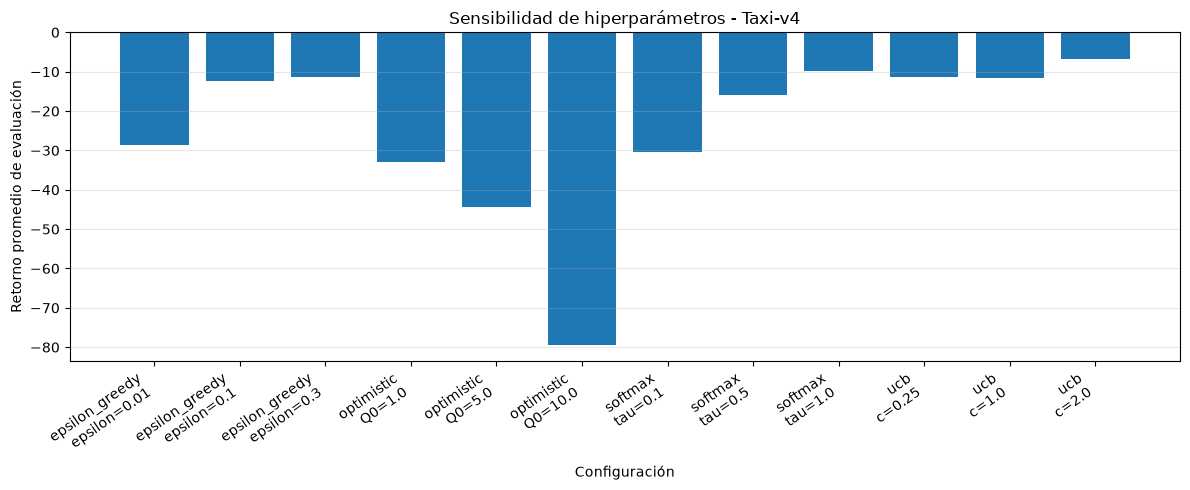

In [32]:
# Elegir el entorno donde hubo mayor diferencia entre estrategias
diferencias = (
    summary.groupby("env")["eval_return_mean"]
    .agg(lambda x: x.max() - x.min())
    .sort_values(ascending=False)
)

sensitivity_env = diferencias.index[0]
config = ENV_CONFIG[sensitivity_env]

print("Entorno elegido para sensibilidad:", sensitivity_env)


# Configuraciones a probar
configuraciones = [
    ("epsilon_greedy", "epsilon", 0.01, {"epsilon": 0.01, "q0": 0}),
    ("epsilon_greedy", "epsilon", 0.10, {"epsilon": 0.10, "q0": 0}),
    ("epsilon_greedy", "epsilon", 0.30, {"epsilon": 0.30, "q0": 0}),

    ("optimistic", "Q0", 1, {"epsilon": 0.01, "q0": 1}),
    ("optimistic", "Q0", 5, {"epsilon": 0.01, "q0": 5}),
    ("optimistic", "Q0", 10, {"epsilon": 0.01, "q0": 10}),

    ("ucb", "c", 0.25, {"c": 0.25, "q0": 0}),
    ("ucb", "c", 1, {"c": 1, "q0": 0}),
    ("ucb", "c", 2, {"c": 2, "q0": 0}),

    ("softmax", "tau", 0.10, {"temperature": 0.10, "q0": 0}),
    ("softmax", "tau", 0.50, {"temperature": 0.50, "q0": 0}),
    ("softmax", "tau", 1.00, {"temperature": 1.00, "q0": 0})
]


resultados_sensibilidad = []

for strategy, hiperparametro, valor, params in configuraciones:

    for run in range(10):

        q, history, counts = train_q_learning(
            env_id=sensitivity_env,
            strategy=strategy,
            episodes=config["episodes"],
            max_steps=config["max_steps"],
            alpha=ALPHA,
            gamma=GAMMA,
            seed=SEED + run,
            env_kwargs=config["kwargs"],
            **params
        )

        evaluation = evaluate_policy(
            env_id=sensitivity_env,
            q=q,
            n_episodes=100,
            max_steps=config["max_steps"],
            seed=SEED + 10000 + run,
            env_kwargs=config["kwargs"]
        )

        cutoff = history["episode"].max() * 0.9

        train_return = history[
            history["episode"] > cutoff
        ]["return"].mean()

        resultados_sensibilidad.append({
            "strategy": strategy,
            "hiperparametro": hiperparametro,
            "valor": valor,
            "run": run,
            "train_return": train_return,
            "eval_return": evaluation["return"].mean(),
            "eval_success": evaluation["success"].mean()
        })


# Convertir resultados a DataFrame
sensibilidad = pd.DataFrame(resultados_sensibilidad)


# Resumen
sensitivity_summary = (
    sensibilidad
    .groupby(["strategy", "hiperparametro", "valor"])
    .agg(
        train_return=("train_return", "mean"),
        eval_return=("eval_return", "mean"),
        eval_success=("eval_success", "mean")
    )
    .reset_index()
)

display(sensitivity_summary.round(4))


# Gráfica
sensitivity_summary["configuracion"] = (
    sensitivity_summary["strategy"]
    + "\n"
    + sensitivity_summary["hiperparametro"]
    + "="
    + sensitivity_summary["valor"].astype(str)
)

plt.figure(figsize=(12, 5))

plt.bar(
    sensitivity_summary["configuracion"],
    sensitivity_summary["eval_return"]
)

plt.title(f"Sensibilidad de hiperparámetros - {sensitivity_env}")
plt.xlabel("Configuración")
plt.ylabel("Retorno promedio de evaluación")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# Decodificar la dimensión de as utilizable en las tablas Q ya entrenadas
env_bj = gym.make("Blackjack-v1", **ENV_CONFIG["Blackjack-v1"]["kwargs"])
dims = tuple(space.n for space in env_bj.observation_space.spaces)  # (32, 11, 2)
env_bj.close()

def decode_blackjack_state(index, dims):
    player_sum, dealer_card, usable_ace = np.unravel_index(index, dims)
    return int(player_sum), int(dealer_card), bool(usable_ace)

rows = []
for strategy in STRATEGIES:
    q = REPRESENTATIVE_Q[("Blackjack-v1", strategy)]
    for state_idx in range(q.shape[0]):
        player_sum, dealer_card, usable_ace = decode_blackjack_state(state_idx, dims)
        if not (4 <= player_sum <= 21):
            continue  # sumas fuera del rango jugable, sin sentido analizarlas
        rows.append({
            "strategy": strategy,
            "player_sum": player_sum,
            "dealer_card": dealer_card,
            "usable_ace": usable_ace,
            "best_action": int(np.argmax(q[state_idx])),  # 0 = stick, 1 = hit
            "best_value": float(np.max(q[state_idx])),
        })

policy_df = pd.DataFrame(rows)

ace_policy_summary = (
    policy_df.groupby(["strategy", "usable_ace"])
    .agg(
        mean_best_value=("best_value", "mean"),
        pct_hit=("best_action", "mean"),  # fracción de estados donde la política elige "hit"
        n_states=("best_action", "size"),
    )
    .reset_index()
)
display(ace_policy_summary.round(4))

,strategy,usable_ace,mean_best_value,pct_hit,n_states
0,epsilon_greedy,False,-0.0144,0.5253,198
1,epsilon_greedy,True,0.0666,0.3283,198
2,optimistic,False,1.4097,0.3838,198
3,optimistic,True,4.0046,0.2424,198
4,softmax,False,0.0286,0.4899,198
5,softmax,True,0.0768,0.2626,198
6,ucb,False,-0.0029,0.4646,198
7,ucb,True,0.0822,0.3182,198


## 10. Interpretación

Responda citando valores, tablas o figuras del notebook:

1. ¿Qué estrategia aprendió más rápido en cada entorno?

En FrozenLake, optimistic aprendió más rápido: en las curvas de tasa de éxito y retorno de entrenamiento desde los primeros episodios crece y llega a aprox 0.6-0.7 hacia cerca del 1000. En Blackjack las diferencias son mínimas, aunque se ve que el greedy y el UCB aprenden más rápido. En Taxi, está complicado de ver porque hay 3 de las estrategias que tienen una curva muy similar, la única que no ha tenido tan buen desempeño sería softmax, sin decir que es malo.


2. ¿La estrategia con mejor curva de entrenamiento produjo también la mejor política greedy?

No siempre. En FrozenLake sí hay coincidencia: optimistic tuvo la mejor curva de entrenamiento (train_return_last10 = 0.6817) y también la mejor evaluación (eval_return_mean=0.7223). En Blackjack también coincide: ucb ganó en ambas fases (-0.1125 entrenamiento, -0.0333 evaluación). Pero en Taxi el caso de optimista entrenó casi tan bien como ucb, pero tuvo la peor evaluación de las cuatro (-40.3233). Esto muestra que un buen retorno de entrenamiento no garantiza una buena política evaluada.

3. ¿Dónde ayudó y dónde perjudicó la inicialización optimista? Relaciónelo con recompensas negativas y estados poco visitados.

Ayudó en FrozenLake, Q0=5 empujó a explorar sin castigo por hacerlo, lo que encuentra mejor desempeño (eval_success=0.7223). Perjudicó en Taxi, donde cada paso cuesta -1, al obligarlo a visitar las acciones no visitadas con el comienzo optimista, el agente terminó castigado por explorar acciones penalizadas. Esto se ve mejor cuando se analiza la sensibilidad: a mayor Q0, peor eval_return. Algo similar se puede ver en Blackjack, donde optimistic quedó último en eval_return (-0.1060).

4. ¿Cómo se comportó UCB cuando muchos pares estado–acción fueron visitados pocas veces?

En Taxi, ucb obtuvo la mayor cobertura de pares estado-acción de las cuatro estrategias (sa_coverage_mean=0.8000), por la exploración que debe hacer priorizando lo no visitado sin necesitar un Q0 alto u "optimista", lo que deja el mejor eval_return de Taxi (-8.9957) y el mejor train_return (7.3307). Por otro lado, UCB también fue la estrategia menos sensible a su propio parámetro c.

5. ¿Qué efecto tuvo la temperatura de Softmax sobre estabilidad y desempeño?

Con tau = 0.50, softmax fue consistentemente la peor o casi peor estrategia en los tres entornos, en FrozenLake casi no aprendió (eval_success=0.4530), en Blackjack quedó segunda peor (-0.0557) y en Taxi también segunda peor (-15.9657). En la sensibilidad de Taxi el efecto de tau incremental tau = 0.10 dio el peor resultado de softmax (eval_return = -30.386, success = 0.866), tau = 0.50 mejoró y tau=1.00 fue el mejor -9.746/0.914. Esto indica que con temperatura baja softmax toma decisiones muy sensibles a pequeñas diferencias de Q, es decir, poca exploración real, mientras que con temperatura alta permite explorar más antes de explotar. De las cuatro estrategias, softmax fue la más sensible a su propio parámetro.

6. ¿Qué estrategia fue más sensible a la estocasticidad de FrozenLake?

FrozenLake se corrió con is_slippery=True, por lo que la acción elegida no siempre se ejecuta. Softmax fue la más afectada, el ruido de las transiciones hizo que las diferencias entre Q(s,a) fueran pequeñas, y nunca crecer como las demás en su aprendizaje. UCB también mostró algo de sensibilidad, su curva de aprendizaje arrancó tarde en comparación, probablemente por su tema de explorar más. En contraste, optimista fue la más robusta a esto, aprendiendo una política que rodea los huecos.

7. En Blackjack, ¿qué diferencias aparecen entre manos con y sin as utilizable?

Las 4 estrategias muestran que tener un as utilizable se asocia con un mean_best_value más alto y una política que elige "hit" con menor frecuencia, es decir, una política más conservadora. Por ejemplo, en epsilon_greedy el valor promedio pasa de -0.0144 sin as a 0.0666 con as, mientras que pct_hit baja de 52.53% a 32.83%. 

8. ¿Existe una estrategia ganadora para los tres escenarios y todas las métricas?

No. Cada entorno tuvo un ganador distinto en eval_return_mean. UCB ganó en 2 de 3 entornos y nunca fue la peor estrategia en ninguno, lo que lo parece más consistente, pero no ganó en FrozenLake. Softmax sería lo contrario, la menos recomendable.

9. Si el costo de interacción fuera alto, ¿qué estrategia recomendaría y por qué?

Recomendaría UCB. al obligarse a explorar, logra la mayor cobertura de pares estado-acción en Taxi sin arriesgar recompensas muy negativas como sí hace optimista. Además, en la sensibilidad de hiperparámetros UCB fue la estrategia más estable con los cambios de parámetro c

10. Mencione dos amenazas a la validez del experimento.

Fijar los hiperparámetros igual para cada problema, ya que algunos muestran alta sensibilidad a los parámetros y no todos tenían recompensas similares. 

Según las curvas de entrenamiento, se ve que en el horizonte dado por ejemplo en FrozenLake no alcanza a converger. 

## 11. Uso de inteligencia artificial

"""
A partir de este inicio: Ayúdame a crear la función de select action
"""

"""
Ayúdame a hacer un código que me ayude a hacer las pruebas de empates no determinísticos sobre la función anterior
"""

"""
Ahora ayúdame a crear la función de train_q_learning
"""

"""
Ayúdame a crear la función evaluate_policy y la función para correr el experimento
"""

"""
Ahora creemos las métricas y visualizaciones a continuación:
"""

## 12. Conclusiones

No existe una estrategia ganadora para todos los entornos. UCB ganó en 2 de 3 entornos (Blackjack y Taxi) y nunca fue la peor en ninguno, lo que lo hace la opción más consistente, pero en FrozenLake fue superado por optimista. Softmax con tau = 0.50, en cambio, fue consistentemente de las peores estrategias en los tres entornos.

El desempeño de la inicialización optimista depende totalmente de si el entorno castiga la exploración o no. En FrozenLake, donde explorar no tiene costo, Q0=5 ayudó a lograr el mejor desempeño del entorno. En Taxi y Blackjack, donde cada paso puede tener recompensa negativa, ese mismo mecanismo perjudicó el resultado porque el agente terminó pagando por visitar acciones penalizadas antes de que sus estimaciones se ajustaran a la realidad.

Un buen entrenamiento no siempre se traduce en una buena política evaluada. Por ejemplo en Taxi entrenó casi tan bien como UCB pero tuvo la peor evaluación de las cuatro estrategias. Esto confirma que el retorno de entrenamiento no es la única métrica que debería ser evaluada para elegir la estrategia final, hay que mirar la evaluación greedy por separado.

Los resultados están condicionados por decisiones metodológicas que limitan qué tan generalizables son. Se usaron los mismos parámetros para los tres entornos aunque el análisis de sensibilidad muestra que el desempeño de cada estrategia depende fuertemente de su parámetro, y además el horizonte de entrenamiento de FrozenLake no alcanzó a converger del todo, por lo que el orden de las estrategias podría cambiar si se entrenara por más episodios.


## Lista de verificación de entrega

- [ ] Implementé y validé las cuatro estrategias.
- [ ] Q-Learning trata correctamente estados terminales y truncamientos.
- [ ] Comparé tres entornos con semillas y presupuesto equivalentes.
- [ ] Separé entrenamiento y evaluación greedy.
- [ ] Reporté variabilidad entre corridas.
- [ ] Incluí tabla, cuatro visualizaciones y sensibilidad.
- [ ] Respondí todas las preguntas con evidencia.
- [ ] Documenté el uso de IA y escribí conclusiones.
- [ ] Reinicié el kernel y ejecuté todas las celdas.
- [ ] Exporté y revisé el HTML.
